In [2]:
import os
import pandas as pd
from tqdm import tqdm
input_utterances = [
    "50", "51", "500", "501", "1000", "1001", "5000", "5001", "10000", "10001" 
]

In [68]:
# read human data for experiment 1
human_data_kettle, human_data_watch, human_data_laptop = {}, {}, {}
exp1_file = os.path.join("human_data", "experiment1-normalized.csv")
with open(exp1_file, 'r') as f:
    lines = f.readlines()
    for line in lines[1:]:
        data = line.strip().split(',')
        if "watch" in data[1]:
            if (data[2], data[6]) in human_data_watch:
                human_data_watch[(data[2], data[6])].append(data[9])
            else:
                human_data_watch[(data[2], data[6])] = [data[9]]    
        elif "kettle" in data[1]:
            if (data[2], data[6]) in human_data_kettle:
                human_data_kettle[(data[2], data[6])].append(data[9])
            else:
                human_data_kettle[(data[2], data[6])] = [data[9]]
        elif "laptop" in data[1]:
            if (data[2], data[6]) in human_data_laptop:
                human_data_laptop[(data[2], data[6])].append(data[9])
            else:
                human_data_laptop[(data[2], data[6])] = [data[9]]
for key in human_data_watch:
    human_data_watch[key] = pd.Series(human_data_watch[key]).astype(float).mean()
for key in human_data_kettle:
    human_data_kettle[key] = pd.Series(human_data_kettle[key]).astype(float).mean()
for key in human_data_laptop:
    human_data_laptop[key] = pd.Series(human_data_laptop[key]).astype(float).mean()


In [56]:


def get_model_predictions(cost, is_marginal = True):
    model_predictions = {}
    for i, obj in enumerate(["kettle", "watch", "laptop"]):
        model_predictions[obj] = {}
        for utterance in tqdm(input_utterances):
            bash_command = f"source ~/.bash_profile && nvm use 10.1 && webppl rsa.wppl -- --object {obj} --num {utterance} --cost {cost}"
            args = f"/bin/bash -c '{bash_command}'"
            output = os.popen(args).read()
            # parse output
            output = output.split("\n")
            print(output)
            for line in output:
                line = line.strip()
                line = line.split(":")
                if is_marginal:
                    if len(line) == 2 and "Marginal" not in line[0]:
                        model_predictions[obj][(utterance,str(int(line[0])))] = float(line[1])
                    else:
                        continue
                else:
                    if len(line) == 4 and "Marginal" not in line[0]:
                        state = str(int(line[1].split(",")[0]))
                        valence = "1" if "true" in line[2] else "0"
                        model_predictions[obj][(utterance, state, valence)] = float(line[3])
                    else:
                        continue
    return model_predictions

def normalize_model_predictions(model_predictions, lamb):
    normed_model_predictions = {}
    for obj in model_predictions:
        normed_model_predictions[obj] = {}
        for key in model_predictions[obj]:
            powered = model_predictions[obj][key]**lamb
            utterance = key[0]
            preds_obj_utter = [model_predictions[obj][key]**lamb for key in model_predictions[obj] if key[0] == utterance]
            normed_model_predictions[obj][key] = powered/sum(preds_obj_utter)
    return normed_model_predictions




In [77]:
[0.0 + x/100 for x in range(0, 100)]

[0.0,
 0.01,
 0.02,
 0.03,
 0.04,
 0.05,
 0.06,
 0.07,
 0.08,
 0.09,
 0.1,
 0.11,
 0.12,
 0.13,
 0.14,
 0.15,
 0.16,
 0.17,
 0.18,
 0.19,
 0.2,
 0.21,
 0.22,
 0.23,
 0.24,
 0.25,
 0.26,
 0.27,
 0.28,
 0.29,
 0.3,
 0.31,
 0.32,
 0.33,
 0.34,
 0.35,
 0.36,
 0.37,
 0.38,
 0.39,
 0.4,
 0.41,
 0.42,
 0.43,
 0.44,
 0.45,
 0.46,
 0.47,
 0.48,
 0.49,
 0.5,
 0.51,
 0.52,
 0.53,
 0.54,
 0.55,
 0.56,
 0.57,
 0.58,
 0.59,
 0.6,
 0.61,
 0.62,
 0.63,
 0.64,
 0.65,
 0.66,
 0.67,
 0.68,
 0.69,
 0.7,
 0.71,
 0.72,
 0.73,
 0.74,
 0.75,
 0.76,
 0.77,
 0.78,
 0.79,
 0.8,
 0.81,
 0.82,
 0.83,
 0.84,
 0.85,
 0.86,
 0.87,
 0.88,
 0.89,
 0.9,
 0.91,
 0.92,
 0.93,
 0.94,
 0.95,
 0.96,
 0.97,
 0.98,
 0.99]

In [57]:
# run webppl code for all utterances
# us os to run webppl code
cost = [1.0 + x/10 for x in range(0, 30)]
lambda_ = [0.0 + x/100 for x in range(0, 100)]
mses = {}
for c in tqdm(cost):
    model_predictions = get_model_predictions(c, is_marginal = True)
    for l in lambda_:
        normed_model_predictions = normalize_model_predictions(model_predictions, l)
        # compare model predictions with human data
        # sum over mse for all objects
        mse = 0
        for obj in ["kettle", "watch", "laptop"]:
            if obj == "watch":
                for key in human_data_watch:
                    mse += (human_data_watch[key] - normed_model_predictions[obj][key])**2
            elif obj == "kettle":
                for key in human_data_kettle:
                    try:
                        mse += (human_data_kettle[key] - normed_model_predictions[obj][key])**2
                    except:
                        print(key)
                        print(normed_model_predictions[obj])
                        print(human_data_kettle)
                        break
            elif obj == "laptop":
                for key in human_data_laptop:
                    mse += (human_data_laptop[key] - normed_model_predictions[obj][key])**2
        mses[(c, l)] = mse

  0%|          | 0/30 [00:00<?, ?it/s](node:36705) [DEP0079] DeprecationWarning: Custom inspection function on Objects via .inspect() is deprecated


['Now using node v10.1.0 (npm v5.6.0)', 'Marginal:', '    50 : 0.6108515892069817', '    51 : 0.21437795417898242', '    5001 : 0.022917392315753883', '    10001 : 0.022916583492781133', '    10000 : 0.0227026101312484', '    5000 : 0.022060083429420597', '    1001 : 0.021846678889651434', '    1000 : 0.02141831263691317', '    500 : 0.02056139871319977', '    501 : 0.020347397005067484', '']


(node:37189) [DEP0079] DeprecationWarning: Custom inspection function on Objects via .inspect() is deprecated


['Now using node v10.1.0 (npm v5.6.0)', 'Marginal:', '    51 : 0.6068205099541898', '    50 : 0.21766622524033735', '    10001 : 0.02302177913358317', '    5001 : 0.02301243765103209', '    10000 : 0.02280430877450665', '    5000 : 0.02215890380919043', '    1001 : 0.02193486385607683', '    1000 : 0.021504768486349832', '    500 : 0.020646673032701693', '    501 : 0.02042953006203233', '']


(node:37672) [DEP0079] DeprecationWarning: Custom inspection function on Objects via .inspect() is deprecated


...

['Now using node v10.1.0 (npm v5.6.0)', 'Marginal:', '    5001 : 0.9203703228847552', '    5000 : 0.04672813381512338', '    10001 : 0.004664522216128698', '    10000 : 0.004289690666843311', '    1001 : 0.004206399498473196', '    50 : 0.0041647407033360015', '    1000 : 0.0040398130650223536', '    501 : 0.0039148739258513645', '    500 : 0.0038732298262541005', '    51 : 0.0037482733982126012', '']


(node:73874) [DEP0079] DeprecationWarning: Custom inspection function on Objects via .inspect() is deprecated


['Now using node v10.1.0 (npm v5.6.0)', 'Marginal:', '    10000 : 0.523796218627088', '    10001 : 0.29072575154078945', '    5001 : 0.025721520959652897', '    5000 : 0.02406421382723167', '    1001 : 0.02383505609389564', '    50 : 0.023603084804829463', '    1000 : 0.022889793881525976', '    501 : 0.022180602710857894', '    500 : 0.021943392848979795', '    51 : 0.02124036470514922', '']


(node:74357) [DEP0079] DeprecationWarning: Custom inspection function on Objects via .inspect() is deprecated
100%|██████████| 30/30 [56:48<00:00, 113.62s/it]

['Now using node v10.1.0 (npm v5.6.0)', 'Marginal:', '    10001 : 0.9220742738762872', '    10000 : 0.04600836082093606', '    5001 : 0.004426200615243012', '    5000 : 0.004141486347743816', '    1001 : 0.004101456433010784', '    50 : 0.004061188285712338', '    1000 : 0.003938912474115335', '    501 : 0.0038169838013993717', '    500 : 0.0037762720877529327', '    51 : 0.003654865257799312', '']


In [58]:
back_mses = mses
print(back_mses)

{(1.0, 0.0): 2.6735580307498448, (1.0, 0.01): 2.626003736950241, (1.0, 0.02): 2.578389306436301, (1.0, 0.03): 2.5307608205376084, (1.0, 0.04): 2.4831664362150985, (1.0, 0.05): 2.4356563796222135, (1.0, 0.06): 2.3882829326512374, (1.0, 0.07): 2.341100412085429, (1.0, 0.08): 2.29416514099334, (1.0, 0.09): 2.247535412021233, (1.0, 0.1): 2.2012714422632955, (1.0, 0.11): 2.1554353194168656, (1.0, 0.12): 2.110090938961923, (1.0, 0.13): 2.0653039321401634, (1.0, 0.14): 2.0211415845493756, (1.0, 0.15): 1.9776727452133853, (1.0, 0.16): 1.9349677260364802, (1.0, 0.17): 1.8930981916038745, (1.0, 0.18): 1.85213703934603, (1.0, 0.19): 1.8121582701445478, (1.0, 0.2): 1.7732368495202415, (1.0, 0.21): 1.7354485596097504, (1.0, 0.22): 1.6988698422050676, (1.0, 0.23): 1.6635776332002303, (1.0, 0.24): 1.62964918886046, (1.0, 0.25): 1.597161904400821, (1.0, 0.26): 1.5661931254330828, (1.0, 0.27): 1.5368199529105189, (1.0, 0.28): 1.5091190422697587, (1.0, 0.29): 1.483166397536121, (1.0, 0.3): 1.45903716122

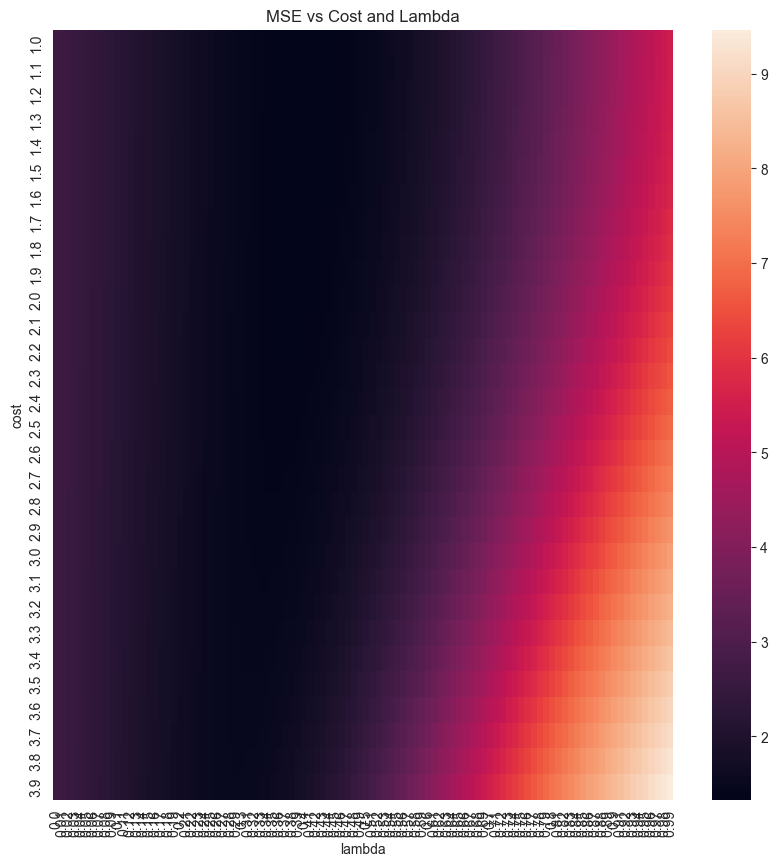

In [59]:
# plot mse vs cost and lambda as a grid
# mse is represented by color
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# convert mses to a matrix
mses_matrix = np.zeros((len(cost), len(lambda_)))
for key in mses.keys():
    mses_matrix[cost.index(key[0]), lambda_.index(key[1])] = mses[key]

# plot
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(mses_matrix, ax=ax, xticklabels=lambda_, yticklabels=cost)
ax.set_xlabel("lambda")
ax.set_ylabel("cost")
ax.set_title("MSE vs Cost and Lambda")
plt.show()

In [60]:
# get all best costs and lambdas
min_mse = min(mses.values())
best_costs = []
best_lambdas = []
for key in mses.keys():
    if mses[key] == min_mse:
        best_costs.append(key[0])
        best_lambdas.append(key[1])

print(best_costs, best_lambdas)
# model_predictions = get_model_predictions(best_cost)
# normed_model_predictions = normalize_model_predictions(model_predictions, best_lambda)
# model_predictions = normed_model_predictions

[1.2] [0.4]


In [61]:
## rerun with best cost and lambda for plotting
print(best_costs[0], best_lambdas[0])
best_model_predictions = get_model_predictions(best_costs[0], is_marginal=True)
best_normed_model_predictions = normalize_model_predictions(best_model_predictions, best_lambdas[0])

1.2 0.4


 10%|█         | 1/10 [00:04<00:40,  4.46s/it]

['Now using node v10.1.0 (npm v5.6.0)', 'Marginal:', '    50 : 0.59643583596668', '    51 : 0.22231960089606095', '    5001 : 0.023766322578756657', '    10001 : 0.023765525910795136', '    10000 : 0.023543615497619283', '    5000 : 0.02287728675712063', '    1001 : 0.022655936617441103', '    1000 : 0.022211702566118728', '    500 : 0.02132305577159476', '    501 : 0.02110111743781278', '']


(node:75328) [DEP0079] DeprecationWarning: Custom inspection function on Objects via .inspect() is deprecated
 20%|██        | 2/10 [00:08<00:33,  4.22s/it]

['Now using node v10.1.0 (npm v5.6.0)', 'Marginal:', '    51 : 0.6231529101276447', '    50 : 0.20862445899542742', '    10001 : 0.02206550599911561', '    5001 : 0.02205651734556884', '    10000 : 0.021857060155021143', '    5000 : 0.02123846411289793', '    1001 : 0.021023696809182965', '    1000 : 0.0206114674599833', '    500 : 0.0197890249081739', '    501 : 0.019580894086984144', '']


...

['Now using node v10.1.0 (npm v5.6.0)', 'Marginal:', '    5001 : 0.6544061666959918', '    5000 : 0.20279797197751703', '    10001 : 0.020244462278749473', '    10000 : 0.01861752917554557', '    1001 : 0.018256166876372264', '    50 : 0.018074987634890072', '    1000 : 0.017533287819941477', '    501 : 0.016991154388719624', '    500 : 0.016810529212475438', '    51 : 0.016267743939797095', '']


(node:88387) [DEP0079] DeprecationWarning: Custom inspection function on Objects via .inspect() is deprecated
 90%|█████████ | 9/10 [00:34<00:03,  3.81s/it]

['Now using node v10.1.0 (npm v5.6.0)', 'Marginal:', '    10000 : 0.5983537084730626', '    10001 : 0.24520858344065186', '    5001 : 0.02169429746362568', '    5000 : 0.02029700837107098', '    1001 : 0.0201030647867026', '    50 : 0.019907022577198265', '    1000 : 0.01930593444010726', '    501 : 0.01870790429964298', '    500 : 0.01850795465000448', '    51 : 0.01791452149793331', '']


(node:88870) [DEP0079] DeprecationWarning: Custom inspection function on Objects via .inspect() is deprecated
100%|██████████| 10/10 [00:37<00:00,  3.78s/it]

['Now using node v10.1.0 (npm v5.6.0)', 'Marginal:', '    10001 : 0.6596906517982825', '    10000 : 0.20092309378703432', '    5001 : 0.01932964961544249', '    5000 : 0.01808676314311335', '    1001 : 0.01791133918530554', '    50 : 0.017735126272269416', '    1000 : 0.017201614795393772', '    501 : 0.016669252938993677', '    500 : 0.01649157106646102', '    51 : 0.0159609373977039', '']


In [62]:
# plot human data and model predictions and show correlation
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns
%matplotlib inline

# plot human data and model predictions
# make a list of human data and model predictions
plot_data_kettle = []
plot_data_watch = []
plot_data_laptop = []
for obj in ["kettle", "watch", "laptop"]:
    for key in best_model_predictions[obj].keys():
        if obj == "kettle":
            plot_data_kettle.append([human_data_kettle[key], best_model_predictions[obj][key]])
        elif obj == "watch":
            plot_data_watch.append([human_data_watch[key], best_model_predictions[obj][key]])
        elif obj == "laptop":
            plot_data_laptop.append([human_data_laptop[key], best_model_predictions[obj][key]])

# plot data
plot_data_kettle = np.array(plot_data_kettle)
plot_data_watch = np.array(plot_data_watch)
plot_data_laptop = np.array(plot_data_laptop)

In [64]:
# create a plotting df of RSA model
df_rsa_wide = pd.DataFrame(best_model_predictions).rename_axis(["utterance", "state"]).reset_index()
df_rsa_wide["model"] = "Llama-3.1-8b-inst-RSA"
# make it long format over objects
df_rsa_wide = df_rsa_wide.rename(columns={"kettle": "electric kettle"})
df_rsa_long = pd.melt(df_rsa_wide, id_vars=["utterance", "state", "model"], value_vars=["electric kettle", "watch", "laptop"], var_name="item", value_name="probability")
df_rsa_long

,utterance,state,model,item,probability
0,50,50,Llama-3.1-8b-inst-RSA,electric kettle,0.596436
1,50,51,Llama-3.1-8b-inst-RSA,electric kettle,0.222320
2,50,5001,Llama-3.1-8b-inst-RSA,electric kettle,0.023766
3,50,10001,Llama-3.1-8b-inst-RSA,electric kettle,0.023766
4,50,10000,Llama-3.1-8b-inst-RSA,electric kettle,0.023544
...,...,...,...,...,...
295,10001,1000,Llama-3.1-8b-inst-RSA,laptop,0.017202
296,10001,500,Llama-3.1-8b-inst-RSA,laptop,0.016492
297,10001,501,Llama-3.1-8b-inst-RSA,laptop,0.016669
298,10001,50,Llama-3.1-8b-inst-RSA,laptop,0.017735


In [69]:
# transform the dict into a df with three columns, where each value of the key is in a separate column
df_human_kettle = pd.DataFrame.from_dict(human_data_kettle, orient='index', columns=['stateProb']).reset_index()
# Split the tuple key into two columns: 'utterance' and 'state'
df_human_kettle[['utterance', 'state']] = pd.DataFrame(df_human_kettle['index'].tolist(), index=df_human_kettle.index)
# Drop the original 'index' column
df_human_kettle = df_human_kettle.drop(columns='index')
# Reorder columns
df_human_kettle = df_human_kettle[['utterance', 'state', 'stateProb']]
df_human_kettle["item"] = "electric kettle"
df_human_watch = pd.DataFrame.from_dict(human_data_watch, orient='index', columns=['stateProb']).reset_index()
# Split the tuple key into two columns: 'utterance' and 'state'
df_human_watch[['utterance', 'state']] = pd.DataFrame(df_human_watch['index'].tolist(), index=df_human_watch.index)
# Drop the original 'index' column
df_human_watch = df_human_watch.drop(columns='index')
# Reorder columns
df_human_watch = df_human_watch[['utterance', 'state', 'stateProb']]
df_human_watch["item"] = "watch"
df_human_laptop = pd.DataFrame.from_dict(human_data_laptop, orient='index', columns=['stateProb']).reset_index()
# Split the tuple key into two columns: 'utterance' and 'state'
df_human_laptop[['utterance', 'state']] = pd.DataFrame(df_human_laptop['index'].tolist(), index=df_human_laptop.index)
# Drop the original 'index' column
df_human_laptop = df_human_laptop.drop(columns='index')
# Reorder columns
df_human_laptop = df_human_laptop[['utterance', 'state', 'stateProb']]
df_human_laptop["item"] = "laptop"

df_human_rsa = pd.concat([df_human_kettle, df_human_watch, df_human_laptop])

In [46]:
def categorize_predictions(row):
    state = int(row["state"])
    utterance = int(row["utterance"])
    if state == utterance:
        interpretation = "exact"
    elif abs(state - utterance) < 5:
        interpretation = "fuzzy"
    elif utterance > state:
        interpretation = "hyperbolic"
    else:
        interpretation = "other"

    return interpretation

In [68]:
# rerun full simulations (non marginalized) with best cost and lambda
# NOTE: one needs to comment out the outputting of the full state / marginalization manually in the wppl file!!!
print(best_costs[0], best_lambdas[0])
best_model_predictions = get_model_predictions(best_costs[0], is_marginal=False)
best_normed_model_predictions = normalize_model_predictions(best_model_predictions, best_lambdas[0])

1.2 0.4


 10%|█         | 1/10 [00:04<00:40,  4.51s/it]

['Now using node v10.1.0 (npm v5.6.0)', 'Marginal:', '    {"price":50,"valence":false} : 0.5675583739123553', '    {"price":51,"valence":false} : 0.21253846936502846', '    {"price":50,"valence":true} : 0.02887746205432462', '    {"price":10001,"valence":false} : 0.02268751804339772', '    {"price":5001,"valence":false} : 0.022592491789812805', '    {"price":10000,"valence":false} : 0.0224519506250482', '    {"price":5000,"valence":false} : 0.021816518060188347', '    {"price":1001,"valence":false} : 0.021514121430789637', '    {"price":1000,"valence":false} : 0.021092275912538858', '    {"price":500,"valence":false} : 0.02026989917590682', '    {"price":501,"valence":false} : 0.020037662116911905', '    {"price":51,"valence":true} : 0.009781131531032454', '    {"price":5001,"valence":true} : 0.0011738307889438528', '    {"price":1001,"valence":true} : 0.0011418151866514684', '    {"price":1000,"valence":true} : 0.001119426653579871', '    {"price":10000,"valence":true} : 0.00109166487

(node:89853) [DEP0079] DeprecationWarning: Custom inspection function on Objects via .inspect() is deprecated
 20%|██        | 2/10 [00:08<00:33,  4.23s/it]

['Now using node v10.1.0 (npm v5.6.0)', 'Marginal:', '    {"price":51,"valence":false} : 0.5966790673305307', '    {"price":50,"valence":false} : 0.19897167764585438', '    {"price":51,"valence":true} : 0.026473842797113876', '    {"price":10001,"valence":false} : 0.021169130075698525', '    {"price":5001,"valence":false} : 0.021080463562292456', '    {"price":10000,"valence":false} : 0.020949328274941868', '    {"price":5000,"valence":false} : 0.020356422757726558', '    {"price":1001,"valence":false} : 0.02007426436693434', '    {"price":1000,"valence":false} : 0.0196806513401317', '    {"price":500,"valence":false} : 0.01891331310261752', '    {"price":501,"valence":false} : 0.018696618773125125', '    {"price":50,"valence":true} : 0.009652781349572957', '    {"price":5001,"valence":true} : 0.0009760537832763734', '    {"price":1001,"valence":true} : 0.0009494324422486181', '    {"price":1000,"valence":true} : 0.0009308161198515863', '    {"price":10000,"valence":true} : 0.000907731

...

['Now using node v10.1.0 (npm v5.6.0)', 'Marginal:', '    {"price":5001,"valence":false} : 0.6310468370632494', '    {"price":5000,"valence":false} : 0.19489240859036977', '    {"price":5001,"valence":true} : 0.023359329632742207', '    {"price":10001,"valence":false} : 0.019530545694946104', '    {"price":10000,"valence":false} : 0.01797973941113756', '    {"price":1001,"valence":false} : 0.017612367099906736', '    {"price":50,"valence":false} : 0.017492198586887324', '    {"price":1000,"valence":false} : 0.01689731927130848', '    {"price":501,"valence":false} : 0.01635773554217165', '    {"price":500,"valence":false} : 0.016166911557587413', '    {"price":51,"valence":false} : 0.015710451912644467', '    {"price":5000,"valence":true} : 0.007905563387147149', '    {"price":10001,"valence":true} : 0.0007139165838033573', '    {"price":1001,"valence":true} : 0.000643799776465528', '    {"price":500,"valence":true} : 0.000643617654888027', '    {"price":10000,"valence":true} : 0.000637

(node:3229) [DEP0079] DeprecationWarning: Custom inspection function on Objects via .inspect() is deprecated
 90%|█████████ | 9/10 [00:33<00:03,  3.90s/it]

['Now using node v10.1.0 (npm v5.6.0)', 'Marginal:', '    {"price":10000,"valence":false} : 0.5780890507341262', '    {"price":10001,"valence":false} : 0.2367150328358196', '    {"price":5001,"valence":false} : 0.020951105349470325', '    {"price":10000,"valence":true} : 0.020264657738936605', '    {"price":5000,"valence":false} : 0.019524270393050117', '    {"price":1001,"valence":false} : 0.019433547935647767', '    {"price":50,"valence":false} : 0.01930095357482896', '    {"price":1000,"valence":false} : 0.018644561641271762', '    {"price":501,"valence":false} : 0.018049183052692847', '    {"price":500,"valence":false} : 0.017838627195512883', '    {"price":51,"valence":false} : 0.017334968014417657', '    {"price":10001,"valence":true} : 0.00849355060483231', '    {"price":5000,"valence":true} : 0.0007727379780208696', '    {"price":5001,"valence":true} : 0.0007431921141553662', '    {"price":1001,"valence":true} : 0.0006695168510548457', '    {"price":500,"valence":true} : 0.0006

(node:3716) [DEP0079] DeprecationWarning: Custom inspection function on Objects via .inspect() is deprecated
100%|██████████| 10/10 [00:38<00:00,  3.80s/it]

['Now using node v10.1.0 (npm v5.6.0)', 'Marginal:', '    {"price":10001,"valence":false} : 0.6365602474168519', '    {"price":10000,"valence":false} : 0.19405483549040314', '    {"price":10001,"valence":true} : 0.023130404381431026', '    {"price":5001,"valence":false} : 0.018647993702355686', '    {"price":5000,"valence":false} : 0.01737800775947569', '    {"price":1001,"valence":false} : 0.01729725823404105', '    {"price":50,"valence":false} : 0.017179239696867334', '    {"price":1000,"valence":false} : 0.01659500356998625', '    {"price":501,"valence":false} : 0.016065073717353547', '    {"price":500,"valence":false} : 0.015877663829751348', '    {"price":51,"valence":false} : 0.01542937085997566', '    {"price":10000,"valence":true} : 0.006868258296631337', '    {"price":5000,"valence":true} : 0.0007087553836376697', '    {"price":5001,"valence":true} : 0.000681655913086818', '    {"price":1001,"valence":true} : 0.0006140809512644998', '    {"price":500,"valence":true} : 0.000613

In [70]:
# save simulation results to pdf
best_model_preds_wide = pd.DataFrame(best_normed_model_predictions).rename_axis(["utterance", "state", "affect"]).reset_index()
best_model_preds_wide["model"] = "Llama-3-8b-inst-RSA"
# make it long format over objects
best_model_preds_long = pd.melt(best_model_preds_wide, id_vars=["utterance", "state", "affect", "model"], value_vars=["kettle", "watch", "laptop"], var_name="object", value_name="probability")
best_model_preds_long
# save to csv
# best_model_preds_long.to_csv("human_data/best_model_preds_llama-3-8b-inst-Priors.csv", index=False)

In [65]:
## plot human and RSA results
best_human_rsa = pd.read_csv("human_data/best_model_preds_humanPriors.csv")
print(best_human_rsa.head())
best_human_rsa_marginalized = best_human_rsa.groupby(["utterance", "state", "object", "model"]).agg({"probability": "sum"}).reset_index()
best_human_rsa_marginalized

   utterance  state  affect        model  object  probability
0         50     50       0  gpt-4o-mini  kettle     0.286029
1         50     50       1  gpt-4o-mini  kettle     0.201958
2         50     51       0  gpt-4o-mini  kettle     0.189718
3         50     51       1  gpt-4o-mini  kettle     0.122905
4         50    501       0  gpt-4o-mini  kettle     0.026087


,utterance,state,object,model,probability
0,50,50,kettle,gpt-4o-mini,0.487988
1,50,50,laptop,gpt-4o-mini,0.208199
2,50,50,watch,gpt-4o-mini,0.394720
3,50,51,kettle,gpt-4o-mini,0.312623
4,50,51,laptop,gpt-4o-mini,0.133980
...,...,...,...,...,...
295,10001,10000,laptop,gpt-4o-mini,0.119629
296,10001,10000,watch,gpt-4o-mini,0.129944
297,10001,10001,kettle,gpt-4o-mini,0.201890
298,10001,10001,laptop,gpt-4o-mini,0.214504


In [66]:
best_human_rsa_marginalized["object"] = best_human_rsa_marginalized["object"].replace({"kettle": "electric kettle"})
best_human_rsa_marginalized = best_human_rsa_marginalized.rename(columns={"object": "item"})
best_human_rsa_marginalized['utterance'] = best_human_rsa_marginalized['utterance'].astype(str)
best_human_rsa_marginalized['state'] = best_human_rsa_marginalized['state'].astype(str)

<Figure size 1200x800 with 0 Axes>

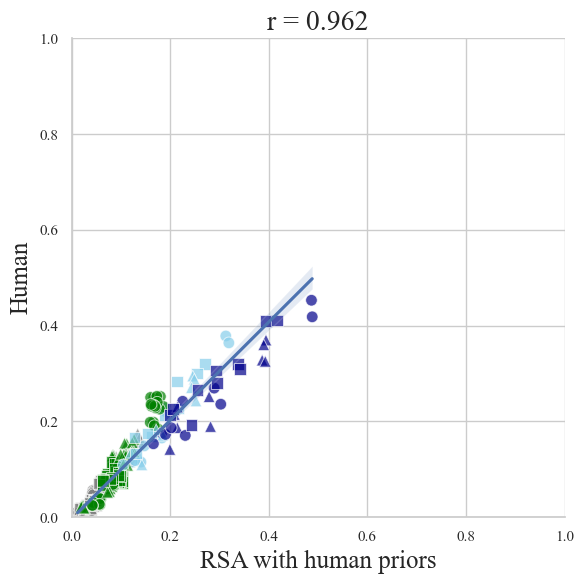

In [73]:
# recreate the plot with the same formatting as 2A with llm data
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines

df_summary = pd.merge(best_human_rsa_marginalized, df_human_rsa, on=["utterance", "state", "item"])
df_summary["interpretationType"] = df_summary.apply(categorize_predictions, axis=1)
sns.set(style = "whitegrid", font="Times New Roman")
# Define color palette and markers
color_palette = {
    'exact': 'darkblue',
    'fuzzy': 'skyblue',
    'hyperbolic': 'green',
    'other': 'gray'
}

markers = {
    'electric kettle': 'o',  # Circle
    'laptop': '^',  # Triangle
    'watch': 's'  # Square
}

# Create the correlation plot using FacetGrid
plt.figure(figsize=(12, 8))
plot_grid = sns.FacetGrid(data=df_summary, col='model', col_wrap=1, height=6, aspect=1)

# Define a custom plotting function to add scatter and regression lines per facet
def scatter_with_reg(data, **kwargs):
    sns.scatterplot(
        data=data, 
        x='probability', 
        y='stateProb', 
        style='item', 
        hue='interpretationType', 
        palette=color_palette, 
        markers=markers, 
        s=70, alpha=0.7, 
        **kwargs
    )
    sns.regplot(
        data=data, 
        x='probability', 
        y='stateProb', 
        scatter=False, 
        ci=95, 
        # color='gray', 
        **kwargs
    )

# Map the custom function to the FacetGrid
plot_grid.map_dataframe(scatter_with_reg)

# Set plot labels and titles
plot_grid.set_axis_labels('RSA with human priors', 'Human', fontsize=18)
plot_grid.set_titles(col_template="{col_name}")

# Calculate and display correlation coefficient for each model
for ax, model in zip(plot_grid.axes.flat, df_summary['model'].unique()):
    subset = df_summary[df_summary['model'] == model]
    correlation_coefficient = subset['probability'].corr(subset['stateProb'])
    ax.set_title(f"r = {round(correlation_coefficient, 3)}", fontsize=20)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

# Add legends
# legend_labels = df_summary['interpretationType'].unique()
# legend_handles = [mlines.Line2D([], [], color=color_palette[label], marker='o', linestyle='None', markersize=6, label=label) for label in legend_labels]
# legend1 = plt.legend(handles=legend_handles, title='Interpretation Type', bbox_to_anchor=(1.0, 1), loc='upper left', fontsize=16)
# plt.gca().add_artist(legend1)

# domain_labels = df_summary['item'].unique()
# domain_handles = [mlines.Line2D([], [], color='black', marker=markers[label], linestyle='None', markersize=6, label=label) for label in domain_labels]
# plt.legend(handles=domain_handles, title='Domain', bbox_to_anchor=(1.0, 0.5), loc='upper left', fontsize=16)

# Adjust layout
plt.tight_layout()
plt.show()

In [38]:
### RSA with gpt priors vs zero-shot GPT

## plot human and RSA results
best_gpt_rsa_claude = pd.read_csv("results/rsa/best_model_preds_claude-3-5-sonnet-Priors.csv")
print(best_gpt_rsa_claude.head())
best_gpt_rsa_claude_marginalized = best_gpt_rsa_claude.groupby(["utterance", "state", "object", "model"]).agg({"probability": "sum"}).reset_index()
best_gpt_rsa_claude_marginalized

best_gpt_rsa_claude_marginalized["object"] = best_gpt_rsa_claude_marginalized["object"].replace({"kettle": "electric kettle"})
best_gpt_rsa_claude_marginalized = best_gpt_rsa_claude_marginalized.rename(columns={"object": "item"})
best_gpt_rsa_claude_marginalized['utterance'] = best_gpt_rsa_claude_marginalized['utterance'].astype(str)
best_gpt_rsa_claude_marginalized['state'] = best_gpt_rsa_claude_marginalized['state'].astype(str)
best_gpt_rsa_claude_marginalized['model'] = 'claude-3-5-sonnet-20241022'

   utterance  state  affect        model  object  probability
0         50     50       0  gpt-4o-mini  kettle     0.248816
1         50     50       1  gpt-4o-mini  kettle     0.199275
2         50     51       0  gpt-4o-mini  kettle     0.190747
3         50     51       1  gpt-4o-mini  kettle     0.142340
4         50    500       1  gpt-4o-mini  kettle     0.033496


In [39]:
best_gpt_rsa = pd.read_csv("results/rsa/best_model_preds_gpt-4o-miniPriors.csv")
print(best_gpt_rsa.head())
best_gpt_rsa_marginalized = best_gpt_rsa.groupby(["utterance", "state", "object", "model"]).agg({"probability": "sum"}).reset_index()
best_gpt_rsa_marginalized

best_gpt_rsa_marginalized["object"] = best_gpt_rsa_marginalized["object"].replace({"kettle": "electric kettle"})
best_gpt_rsa_marginalized = best_gpt_rsa_marginalized.rename(columns={"object": "item"})
best_gpt_rsa_marginalized['utterance'] = best_gpt_rsa_marginalized['utterance'].astype(str)
best_gpt_rsa_marginalized['state'] = best_gpt_rsa_marginalized['state'].astype(str)


   utterance  state  affect        model  object  probability
0         50     50       0  gpt-4o-mini  kettle     0.257721
1         50     50       1  gpt-4o-mini  kettle     0.198638
2         50     51       0  gpt-4o-mini  kettle     0.163640
3         50     51       1  gpt-4o-mini  kettle     0.139066
4         50    501       0  gpt-4o-mini  kettle     0.028467


In [54]:
best_gemini_rsa = pd.read_csv("results/rsa/best_model_preds_gemini-1-5-pro-Priors.csv")
print(best_gemini_rsa.head())
best_gemini_rsa_marginalized = best_gemini_rsa.groupby(["utterance", "state", "object", "model"]).agg({"probability": "sum"}).reset_index()
best_gemini_rsa_marginalized

best_gemini_rsa_marginalized["object"] = best_gemini_rsa_marginalized["object"].replace({"kettle": "electric kettle"})
best_gemini_rsa_marginalized = best_gemini_rsa_marginalized.rename(columns={"object": "item"})
best_gemini_rsa_marginalized['utterance'] = best_gpt_rsa_marginalized['utterance'].astype(str)
best_gemini_rsa_marginalized['state'] = best_gemini_rsa_marginalized['state'].astype(str)
best_gemini_rsa_marginalized['model'] = 'gemini-1.5-pro'

   utterance  state  affect               model  object  probability
0         50     50       0  gemini-1.5-pro-RSA  kettle     0.305259
1         50     51       0  gemini-1.5-pro-RSA  kettle     0.224212
2         50     50       1  gemini-1.5-pro-RSA  kettle     0.171617
3         50     51       1  gemini-1.5-pro-RSA  kettle     0.116684
4         50    501       1  gemini-1.5-pro-RSA  kettle     0.030162


In [55]:
best_rsa_marginalized_all = pd.concat([best_gpt_rsa_marginalized, best_gemini_rsa_marginalized, best_gpt_rsa_claude_marginalized])
best_rsa_marginalized_all['model'].unique()

array(['gpt-4o-mini', 'gemini-1.5-pro', 'claude-3-5-sonnet-20241022'],
      dtype=object)

In [31]:
best_gpt_rsa_marginalized

,utterance,state,item,model,probability
0,50,50,electric kettle,claude-3-5-sonnet-20241022,0.448091
1,50,50,laptop,claude-3-5-sonnet-20241022,0.387889
2,50,50,watch,claude-3-5-sonnet-20241022,0.337754
3,50,51,electric kettle,claude-3-5-sonnet-20241022,0.333087
4,50,51,laptop,claude-3-5-sonnet-20241022,0.062007
...,...,...,...,...,...
295,10001,10000,laptop,claude-3-5-sonnet-20241022,0.111758
296,10001,10000,watch,claude-3-5-sonnet-20241022,0.133727
297,10001,10001,electric kettle,claude-3-5-sonnet-20241022,0.165711
298,10001,10001,laptop,claude-3-5-sonnet-20241022,0.197769


In [42]:
gpt_zeroshot = pd.read_csv("results/llms/experiment_1b_allModels_wHuman_summary.csv")
# gpt_zeroshot = gpt_zeroshot[gpt_zeroshot['model'] == "claude-3-5-sonnet-20241022"]
gpt_zeroshot["processed_utterance"] = gpt_zeroshot["uttered_price"].apply(lambda x: x if x % 10 == 0 else round(x, -1) + 1).astype(str)
gpt_zeroshot = gpt_zeroshot.rename(columns={"processed_utterance": "utterance", "probability": "zeroshot_probability"})
gpt_zeroshot["state"] = gpt_zeroshot["state"].astype(str)

In [43]:
gpt_zeroshot_summary = gpt_zeroshot.groupby(["utterance", "state", "item", "model"]).agg({"zeroshot_probability": "mean", "stateProb": "mean"}).reset_index()
gpt_zeroshot_summary

,utterance,state,item,model,zeroshot_probability,stateProb
0,1000,1000,electric kettle,claude-3-5-sonnet-20241022,0.022136,0.242132
1,1000,1000,electric kettle,gemini-1.5-pro,0.177608,0.242132
2,1000,1000,electric kettle,gpt-4o-mini,0.931205,0.242132
3,1000,1000,electric kettle,gpt-4o-mini_1shotCoT,0.439006,0.242132
4,1000,1000,electric kettle,meta-llama,0.059435,0.242132
...,...,...,...,...,...,...
1495,51,51,watch,claude-3-5-sonnet-20241022,0.233060,0.422113
1496,51,51,watch,gemini-1.5-pro,0.085956,0.422113
1497,51,51,watch,gpt-4o-mini,0.293924,0.422113
1498,51,51,watch,gpt-4o-mini_1shotCoT,0.352969,0.422113


In [52]:
pd.merge(best_rsa_marginalized_all, gpt_zeroshot_summary, on=["utterance", "state", "item", "model"]).value_counts("model")

model
claude-3-5-sonnet-20241022    300
gpt-4o-mini                   300
Name: count, dtype: int64

    utterance  state             item        model  probability
0          50     50  electric kettle  gpt-4o-mini     0.456359
1          50     50           laptop  gpt-4o-mini     0.366095
2          50     50            watch  gpt-4o-mini     0.368929
3          50     51  electric kettle  gpt-4o-mini     0.302706
4          50     51           laptop  gpt-4o-mini     0.239319
..        ...    ...              ...          ...          ...
295     10001  10000           laptop  gpt-4o-mini     0.122532
296     10001  10000            watch  gpt-4o-mini     0.164794
297     10001  10001  electric kettle  gpt-4o-mini     0.166276
298     10001  10001           laptop  gpt-4o-mini     0.217165
299     10001  10001            watch  gpt-4o-mini     0.216073

[300 rows x 5 columns]      utterance  state             item        model  zeroshot_probability  \
2         1000   1000  electric kettle  gpt-4o-mini              0.931205   
7         1000   1000           laptop  gpt-4o-mini   

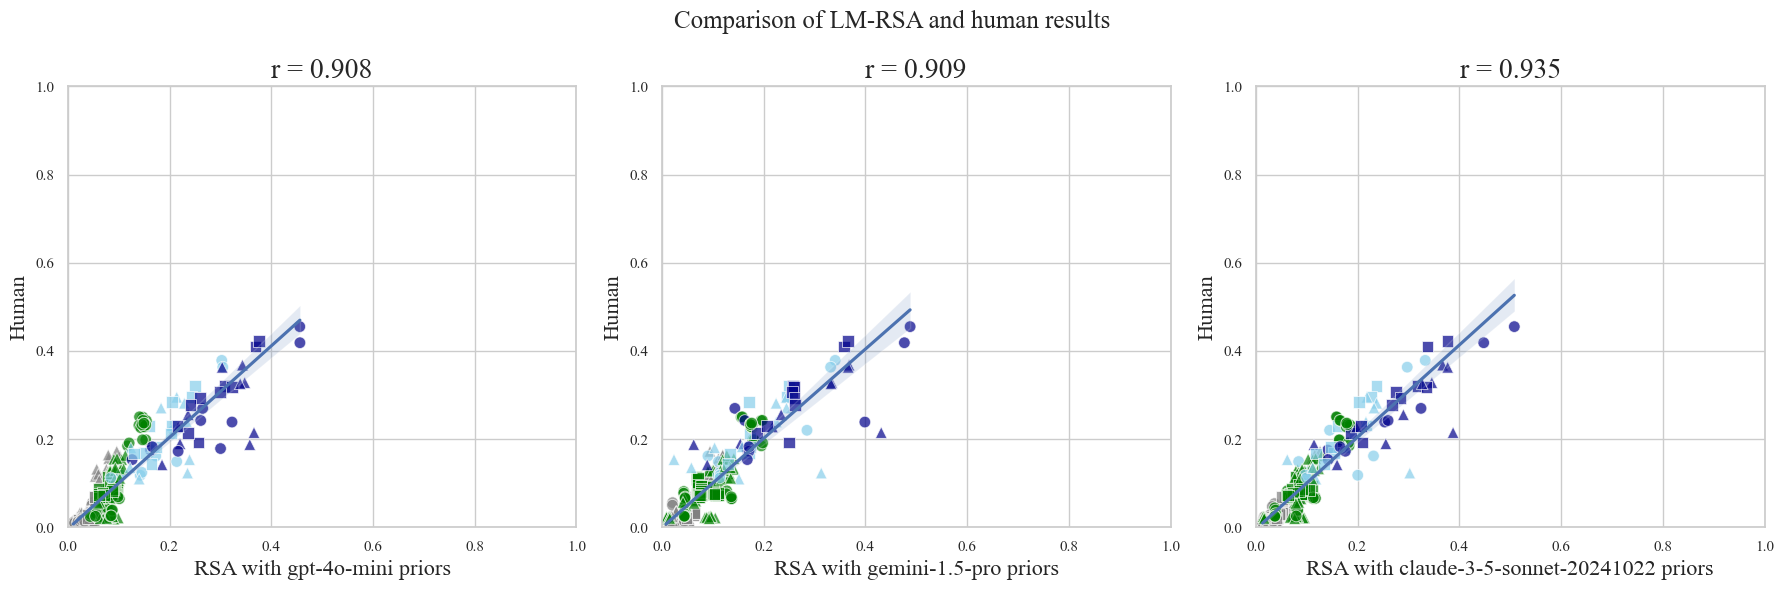

In [62]:
### joint plot for LM-RSA vs humans ###
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

csfont = {'fontname':'Times New Roman'}
plt.rcParams['font.family'] = 'Times New Roman'
# Set the aesthetic style of the plots
# sns.set_style("whitegrid", {'axes.x.grid': True, 'grid.linestyle': '-', 'grid.color': 'lightgray'})

# Create a figure and an array of subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

# Add a title to the figure
fig.suptitle('Comparison of LM-RSA and human results', fontsize=18, **csfont)
# Determine the y-axis limits (shared across all subplots)
y_min, y_max = 0, 1.0  # Assuming your probabilities range between 0 and 1
grid_lines = [0.2, 0.4, 0.6, 0.8, 1.0]  # Define where the grid lines should be

def scatter_with_reg(data, **kwargs):
    sns.scatterplot(
        data=data, 
        x='probability', 
        y='stateProb', 
        style='item', 
        hue='interpretationType', 
        palette=color_palette, 
        markers=markers, 
        s=70, alpha=0.7, 
        **kwargs
    )
    sns.regplot(
        data=data, 
        x='probability', 
        y='stateProb', 
        scatter=False, 
        ci=95, 
        # color='gray', 
        **kwargs
    )
    

for i, m in enumerate(['gpt-4o-mini',  'gemini-1.5-pro', 'claude-3-5-sonnet-20241022']):
    filtered_data_rsa = best_rsa_marginalized_all[best_rsa_marginalized_all['model'] == m]
    filtered_data_human = gpt_zeroshot_summary[gpt_zeroshot_summary['model'] == m]
    print(filtered_data_rsa, filtered_data_human)
    df_summary = pd.merge(filtered_data_rsa, filtered_data_human, on=["utterance", "state", "item", "model"])
    print("df summary")
    print(df_summary.head())
    df_summary["interpretationType"] = df_summary.apply(categorize_predictions, axis=1)

    # Create the categorical line plot
    scatter_with_reg(df_summary, ax=axs[i])


    # Calculate and display correlation coefficient for each model
    # for model in df_summary['model'].unique():
    subset = df_summary[df_summary['model'] == m]
    correlation_coefficient = subset['probability'].corr(subset['stateProb'])
    axs[i].set_title(f"r = {round(correlation_coefficient, 3)}", fontsize=20)
    axs[i].set_xlabel(f'RSA with {m} priors', fontsize=16)
    axs[i].set_ylabel('Human', fontsize=16)
    axs[i].set_ylim(0, 1.0)
    axs[i].set_xlim(0, 1.0)
    axs[i].legend().remove()


plt.tight_layout()

# Show the plot
# plt.savefig("figs/fig1_noYlines.png", dpi=300, bbox_inches="tight")
plt.show()


    utterance  state             item        model  probability
0          50     50  electric kettle  gpt-4o-mini     0.456359
1          50     50           laptop  gpt-4o-mini     0.366095
2          50     50            watch  gpt-4o-mini     0.368929
3          50     51  electric kettle  gpt-4o-mini     0.302706
4          50     51           laptop  gpt-4o-mini     0.239319
..        ...    ...              ...          ...          ...
295     10001  10000           laptop  gpt-4o-mini     0.122532
296     10001  10000            watch  gpt-4o-mini     0.164794
297     10001  10001  electric kettle  gpt-4o-mini     0.166276
298     10001  10001           laptop  gpt-4o-mini     0.217165
299     10001  10001            watch  gpt-4o-mini     0.216073

[300 rows x 5 columns]      utterance  state             item        model  zeroshot_probability  \
2         1000   1000  electric kettle  gpt-4o-mini              0.931205   
7         1000   1000           laptop  gpt-4o-mini   

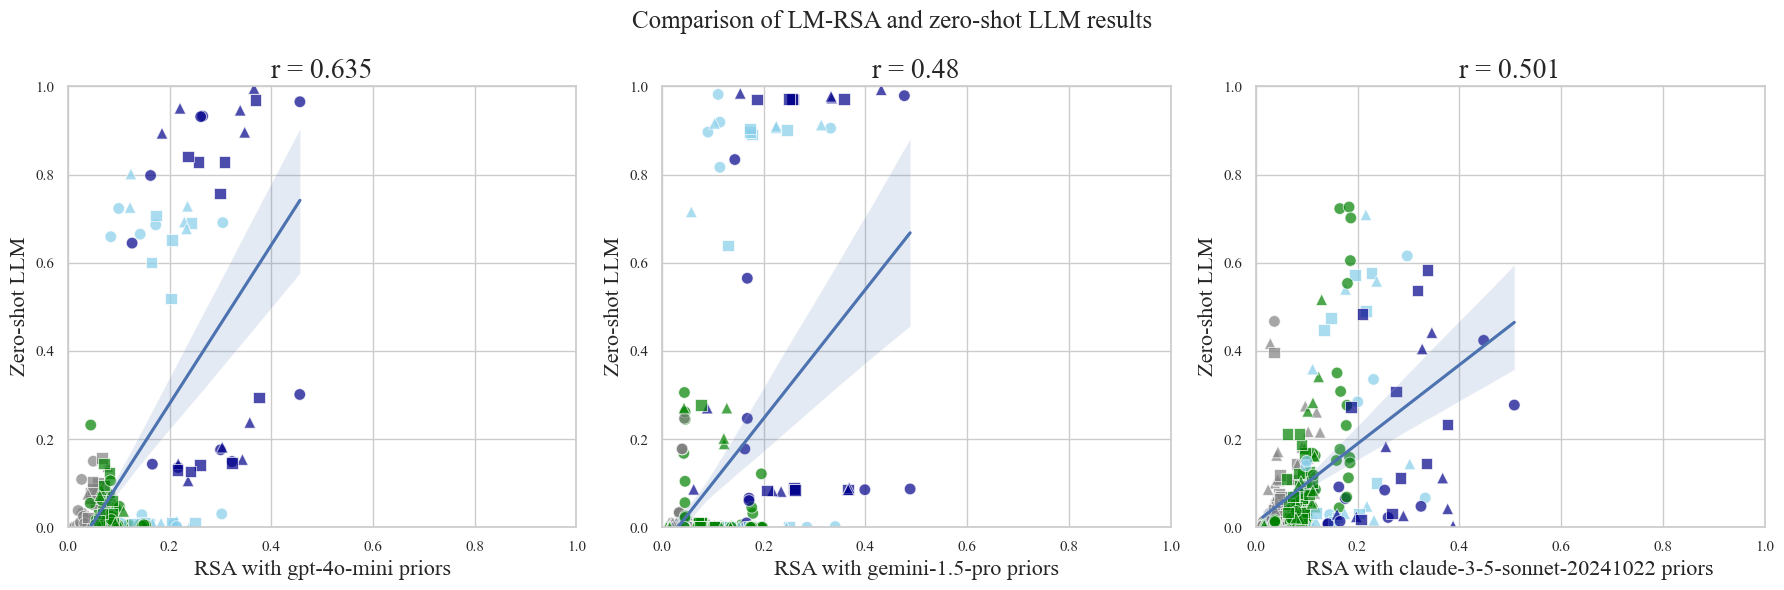

In [64]:
### joint plot for LM-RSA vs LM-zero-shot ###
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

csfont = {'fontname':'Times New Roman'}
plt.rcParams['font.family'] = 'Times New Roman'
# Set the aesthetic style of the plots
# sns.set_style("whitegrid", {'axes.x.grid': True, 'grid.linestyle': '-', 'grid.color': 'lightgray'})

# Create a figure and an array of subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

# Add a title to the figure
fig.suptitle('Comparison of LM-RSA and zero-shot LLM results', fontsize=18, **csfont)

def scatter_with_reg(data, **kwargs):
    sns.scatterplot(
        data=data, 
        x='probability', 
        y='zeroshot_probability', 
        style='item', 
        hue='interpretationType', 
        palette=color_palette, 
        markers=markers, 
        s=70, alpha=0.7, 
        **kwargs
    )
    sns.regplot(
        data=data, 
        x='probability', 
        y='zeroshot_probability', 
        scatter=False, 
        ci=95, 
        # color='gray', 
        **kwargs
    )
    

for i, m in enumerate(['gpt-4o-mini',  'gemini-1.5-pro', 'claude-3-5-sonnet-20241022']):
    filtered_data_rsa = best_rsa_marginalized_all[best_rsa_marginalized_all['model'] == m]
    filtered_data_human = gpt_zeroshot_summary[gpt_zeroshot_summary['model'] == m]
    print(filtered_data_rsa, filtered_data_human)
    df_summary = pd.merge(filtered_data_rsa, filtered_data_human, on=["utterance", "state", "item", "model"])
    print("df summary")
    print(df_summary.head())
    df_summary["interpretationType"] = df_summary.apply(categorize_predictions, axis=1)

    # Create the categorical line plot
    scatter_with_reg(df_summary, ax=axs[i])

    # Calculate and display correlation coefficient for each model
    # for model in df_summary['model'].unique():
    subset = df_summary[df_summary['model'] == m]
    correlation_coefficient = subset['probability'].corr(subset['zeroshot_probability'])
    axs[i].set_title(f"r = {round(correlation_coefficient, 3)}", fontsize=20)
    axs[i].set_xlabel(f'RSA with {m} priors', fontsize=16)
    axs[i].set_ylabel('Zero-shot LLM', fontsize=16)
    axs[i].set_ylim(0, 1.0)
    axs[i].set_xlim(0, 1.0)
    axs[i].legend().remove()


plt.tight_layout()

# Show the plot
# plt.savefig("figs/fig1_noYlines.png", dpi=300, bbox_inches="tight")
plt.show()


    utterance  state             item                       model  probability
0          50     50  electric kettle  claude-3-5-sonnet-20241022     0.448091
1          50     50           laptop  claude-3-5-sonnet-20241022     0.387889
2          50     50            watch  claude-3-5-sonnet-20241022     0.337754
3          50     51  electric kettle  claude-3-5-sonnet-20241022     0.333087
4          50     51           laptop  claude-3-5-sonnet-20241022     0.062007
..        ...    ...              ...                         ...          ...
295     10001  10000           laptop  claude-3-5-sonnet-20241022     0.111758
296     10001  10000            watch  claude-3-5-sonnet-20241022     0.133727
297     10001  10001  electric kettle  claude-3-5-sonnet-20241022     0.165711
298     10001  10001           laptop  claude-3-5-sonnet-20241022     0.197769
299     10001  10001            watch  claude-3-5-sonnet-20241022     0.206427

[300 rows x 5 columns]      utterance  state       

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_57605/1157775821.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data_human["interpretationType"] = filtered_data_human.apply(categorize_predictions, axis=1)
/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_57605/1157775821.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data_human["interpretationType"] = filtered_data_human.apply(categorize_predictions, axis=1)


    utterance  state             item                       model  probability
0          50     50  electric kettle  claude-3-5-sonnet-20241022     0.448091
1          50     50           laptop  claude-3-5-sonnet-20241022     0.387889
2          50     50            watch  claude-3-5-sonnet-20241022     0.337754
3          50     51  electric kettle  claude-3-5-sonnet-20241022     0.333087
4          50     51           laptop  claude-3-5-sonnet-20241022     0.062007
..        ...    ...              ...                         ...          ...
295     10001  10000           laptop  claude-3-5-sonnet-20241022     0.111758
296     10001  10000            watch  claude-3-5-sonnet-20241022     0.133727
297     10001  10001  electric kettle  claude-3-5-sonnet-20241022     0.165711
298     10001  10001           laptop  claude-3-5-sonnet-20241022     0.197769
299     10001  10001            watch  claude-3-5-sonnet-20241022     0.206427

[300 rows x 5 columns]      utterance  state       

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_57605/1157775821.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data_human["interpretationType"] = filtered_data_human.apply(categorize_predictions, axis=1)


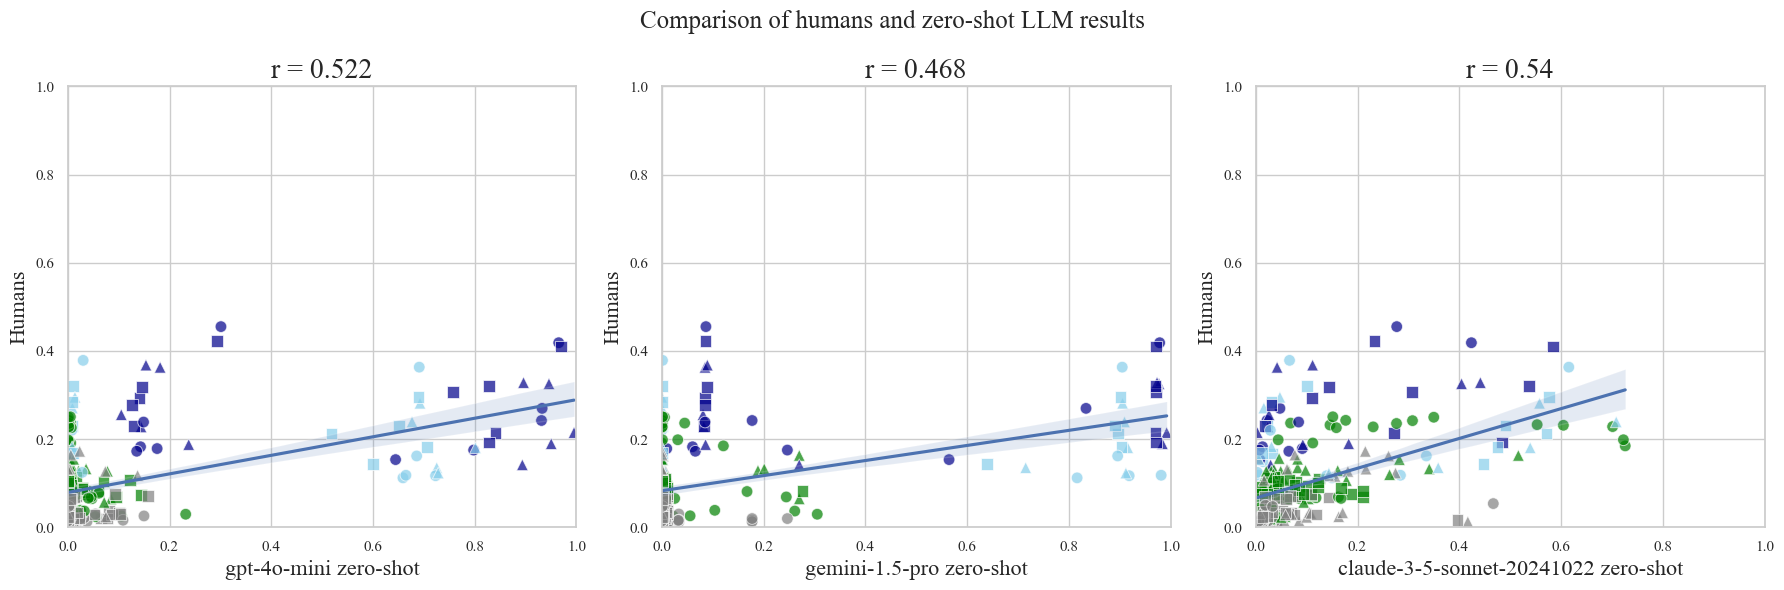

In [75]:
### joint plot for humans vs LM-zero-shot ###
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

csfont = {'fontname':'Times New Roman'}
plt.rcParams['font.family'] = 'Times New Roman'
# Set the aesthetic style of the plots
# sns.set_style("whitegrid", {'axes.x.grid': True, 'grid.linestyle': '-', 'grid.color': 'lightgray'})

# Create a figure and an array of subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

# Add a title to the figure
fig.suptitle('Comparison of humans and zero-shot LLM results', fontsize=18, **csfont)

def scatter_with_reg(data, **kwargs):
    sns.scatterplot(
        data=data, 
        x='zeroshot_probability', 
        y='stateProb', 
        style='item', 
        hue='interpretationType', 
        palette=color_palette, 
        markers=markers, 
        s=70, alpha=0.7, 
        **kwargs
    )
    sns.regplot(
        data=data, 
        x='zeroshot_probability', 
        y='stateProb', 
        scatter=False, 
        ci=95, 
        # color='gray', 
        **kwargs
    )
    

for i, m in enumerate(['gpt-4o-mini',  'gemini-1.5-pro', 'claude-3-5-sonnet-20241022']):
    filtered_data_human = gpt_zeroshot_summary[gpt_zeroshot_summary['model'] == m]
    print(filtered_data_rsa, filtered_data_human)
    filtered_data_human["interpretationType"] = filtered_data_human.apply(categorize_predictions, axis=1)

    # Create the categorical line plot
    scatter_with_reg(filtered_data_human, ax=axs[i])

    # Calculate and display correlation coefficient for each model
    # for model in df_summary['model'].unique():
    subset = filtered_data_human[filtered_data_human['model'] == m]
    correlation_coefficient = subset['zeroshot_probability'].corr(subset['stateProb'])
    axs[i].set_title(f"r = {round(correlation_coefficient, 3)}", fontsize=20)
    axs[i].set_xlabel(f'{m} zero-shot', fontsize=16)
    axs[i].set_ylabel('Humans', fontsize=16)
    axs[i].set_ylim(0, 1.0)
    axs[i].set_xlim(0, 1.0)
    axs[i].legend().remove()


plt.tight_layout()

# Show the plot
# plt.savefig("figs/fig1_noYlines.png", dpi=300, bbox_inches="tight")
plt.show()
